# Hands-on session on Quantum Gates & Circuits

**Tools used:** Qiskit, Qiskit Aer, Matplotlib, Google Colab, coffee!



# Installing Qiskit



In [3]:
!pip -q install "qiskit[visualization]" qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00


# Importing all the tools and libs

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

print("Imports completed.")

Imports completed.


# My Helper functions



In [8]:
# ## Draw Qiskit circuit using Matplotlib
# def draw_circuit(qc, title=None):
#     if title:
#         display(Markdown(f"### {title}"))
#     display(qc.draw(output="mpl", fold=-1))


# ## Show final statevector of a circuit; no measurement
# def show_statevector(qc, title="Statevector"):
#     display(Markdown(f"### {title}"))
#     state = Statevector.from_instruction(qc)
#     display(state.draw("latex"))
#     return state


# ## Show Bloch sphere visualization of a circuit state
# def show_bloch(qc, title="Bloch sphere"):
#     display(Markdown(f"### {title}"))
#     state = Statevector.from_instruction(qc)
#     display(plot_bloch_multivector(state))
#     return state


# ## Util function to show circuit, statevector, and Bloch sphere all tgether
# def show_circuit_state_bloch(qc, title="Quantum circuit"):
#     draw_circuit(qc, title)
#     state = show_statevector(qc, "Final statevector")
#     display(Markdown("### Bloch sphere visualization"))
#     display(plot_bloch_multivector(state))
#     return state


# ## Measure all those qubits and plot a histogram
# def measure_and_plot(qc, shots=1024, title="Measurement result"):
#     measured_qc = qc.copy()
#     measured_qc.measure_all()

#     simulator = AerSimulator()
#     result = simulator.run(measured_qc, shots=shots).result()
#     counts = result.get_counts()

#     draw_circuit(measured_qc, title + " circuit")
#     display(Markdown(f"### {title} histogram"))
#     display(plot_histogram(counts))
#     print("Counts:", counts)
#     return counts


# """
# Prepare useful starting states for one qubit.

# initial_state options:
# - "0"     : |0>
# - "1"     : |1>
# - "+"     : (|0> + |1>) / sqrt(2)
# - "-"     : (|0> - |1>) / sqrt(2)
# - "+i"    : (|0> + i|1>) / sqrt(2)
# - "-i"    : (|0> - i|1>) / sqrt(2)

# """
# def prepare_initial_state(qc, initial_state="0"):
#     if initial_state == "0":
#         pass
#     elif initial_state == "1":
#         qc.x(0)
#     elif initial_state == "+":
#         qc.h(0)
#     elif initial_state == "-":
#         qc.x(0)
#         qc.h(0)
#     elif initial_state == "+i":
#         qc.h(0)
#         qc.s(0)
#     elif initial_state == "-i":
#         qc.h(0)
#         qc.sdg(0)
#     else:
#         raise ValueError("Unknown initial_state. Use '0', '1', '+', '-', '+i', or '-i'.")


# ## Prepare a starting state, apply one gate, and visualize the result... enbtry helper
# def visualize_one_qubit_gate(gate_name, gate_function, initial_state="0"):
#     qc = QuantumCircuit(1)
#     prepare_initial_state(qc, initial_state)
#     gate_function(qc)
#     return show_circuit_state_bloch(qc, f"{gate_name} gate, starting from |{initial_state}>")

# ***Let's GOOooo*** 🚀

# 1. What is a bit in classical computing and a qubit in quantum computing

A classical bit is either:

```text
0 or 1
```

A qubit can be:

```text
|0>, |1>, or a superposition of both
```

A general single-qubit state is written as:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle
$$

where:

$$
|\alpha|^2 + |\beta|^2 = 1
$$

Simple meaning:

- $|\alpha|^2$ is the probability of measuring `0`.
- $|\beta|^2$ is the probability of measuring `1`.

# 2. what is a Bloch sphere

The Bloch sphere is a 3D visualization for **one qubit**.

```text
Top of sphere    -> |0>
Bottom of sphere -> |1>
Equator          -> superposition states
```

please remember:

- Bloch sphere is excellent for visualisation but for single gates only
- For entangled two-qubit states, Bloch spheres alone do not show the full story. For entanglement we also use **statevector** and **measurement histogram**.

# 3. Initial state: |0>

qubits start in state $|0\rangle$ by default. As per the lib we are using

see below:

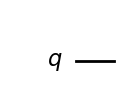

<IPython.core.display.Latex object>

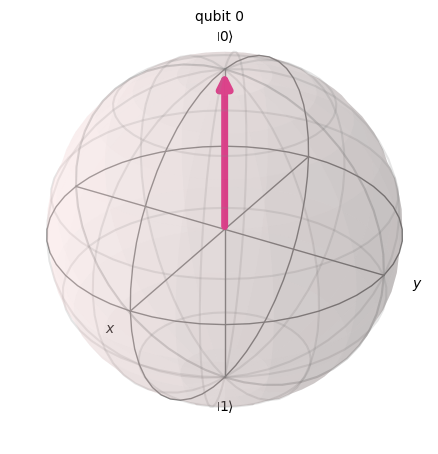

In [9]:
qc = QuantumCircuit(1)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

# 4. Initial state: |1>

But, we can create $|1\rangle$ by applying the `X` gate to $|0\rangle$.

Example:

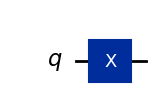

<IPython.core.display.Latex object>

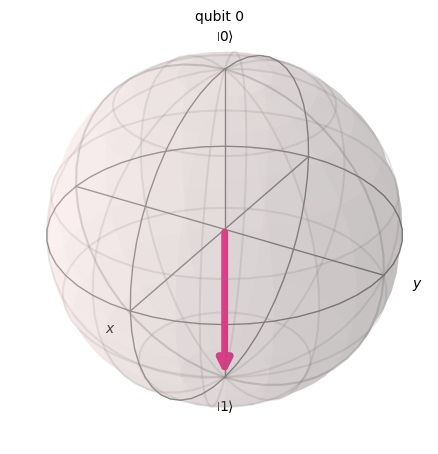

In [10]:
qc = QuantumCircuit(1)

qc.x(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

# We will cover these single-qubit gates:


| # | Gate name | in our code | means |
|---:|---|---|---|
| 1 | `I` | `qc.id(0)` | Do nothing |
| 2 | `X` | `qc.x(0)` | Bit flip |
| 3 | `Y` | `qc.y(0)` | Bit flip with phase |
| 4 | `Z` | `qc.z(0)` | Phase flip |
| 5 | `H` | `qc.h(0)` | Create superposition |
| 6 | `S` | `qc.s(0)` | 90 degree phase rotation |
| 7 | `Sdg` | `qc.sdg(0)` | Reverse S |
| 8 | `T` | `qc.t(0)` | 45 degree phase rotation |
| 9 | `Tdg` | `qc.tdg(0)` | Reverse T |
| 10 | `P` | `qc.p(theta, 0)` | Custom phase rotation |
| 11 | `Rx` | `qc.rx(theta, 0)` | Rotation around X-axis |
| 12 | `Ry` | `qc.ry(theta, 0)` | Rotation around Y-axis |
| 13 | `Rz` | `qc.rz(theta, 0)` | Rotation around Z-axis |
| 14 | `U` | `qc.u(theta, phi, lam, 0)` | General single-qubit gate |

# And Two-qubit gates are:

| Gate name | in the code | what it means? |
|---|---|---|
| `CX` / `CNOT` | `qc.cx(control, target)` | Controlled bit flip |
| `CZ` | `qc.cz(control, target)` | Controlled phase flip |
| `SWAP` | `qc.swap(q0, q1)` | Swap two qubit states |


*Let's begin...*

# 1. Single-qubit basic gates

## 1.1 Identity gate: I

The identity gate does nothing.

$$
I|0\rangle = |0\rangle
$$

This means, it will not change the state.

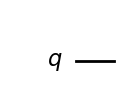

<IPython.core.display.Latex object>

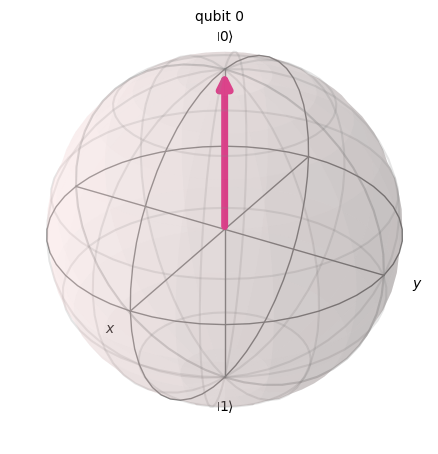

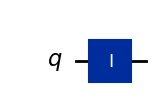

<IPython.core.display.Latex object>

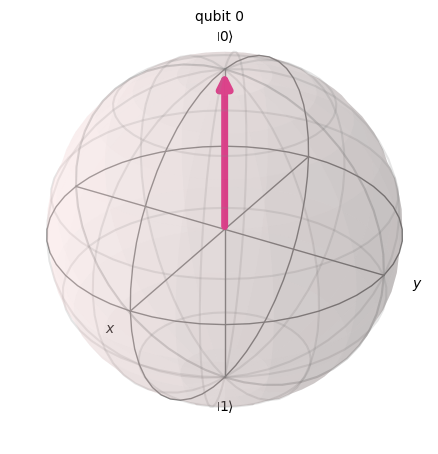

In [13]:
qc = QuantumCircuit(1)

display(qc.draw(output="mpl"))
state = Statevector.from_instruction(qc)
display(state.draw("latex"))
display(plot_bloch_multivector(state))

## applying Identity gate
qc.id(0)

display(qc.draw(output="mpl"))
state = Statevector.from_instruction(qc)
display(state.draw("latex"))
display(plot_bloch_multivector(state))

## 1.2 Pauli-X gate

The `X` gate is like a classical NOT gate.

$$
X|0\rangle = |1\rangle
$$

$$
X|1\rangle = |0\rangle
$$

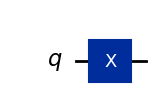

<IPython.core.display.Latex object>

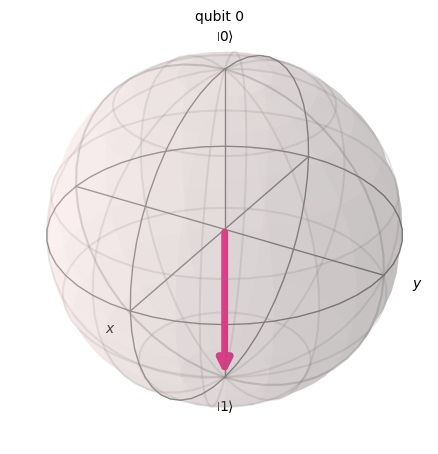

In [14]:
qc = QuantumCircuit(1)

qc.x(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

### Measure after X gate

Since the final state is $|1\rangle$, measurement should give mostly `1`.

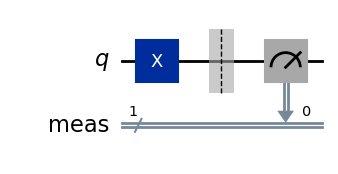

{'1': 1024}


In [22]:
qc = QuantumCircuit(1)

qc.x(0)
qc.measure_all()
display(qc.draw(output="mpl"))
## till now we have only added a measurment box, and not ran or did actual mesearements!

## now we run this circuit, this how we run any circuit:
simulator = AerSimulator()
# Run this quantum circuit qc on the simulator 1024 times. Because quantum measurement is probabilistic.
# One run gives one answer. Many runs give statistics. shots tells how many times to repeat the experiment.
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
# display(plot_histogram(counts))

## 1.3 Pauli-Y gate

The `Y` gate also moves $|0\rangle$ to $|1\rangle$, but with an extra phase factor.

$$
Y|0\rangle = i|1\rangle
$$

The measurement is still `1`, but the state has a phase.

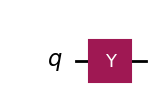

<IPython.core.display.Latex object>

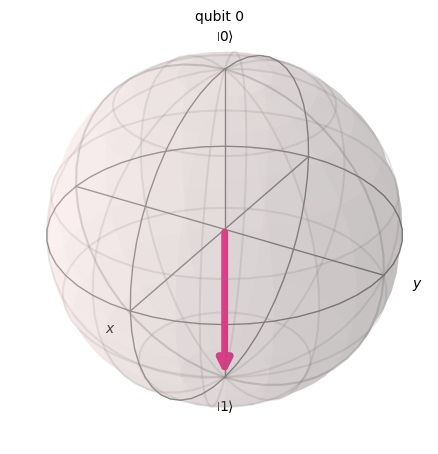

Amplitude of |0> = 0j
Amplitude of |1> = 1j
Phase angle of |1> = 1.5707963267948966 radians
Phase angle of |1> = 90.0 degrees
Phase factor = i
Y|0> = i|1>


In [25]:
qc = QuantumCircuit(1)

qc.y(0)

display(qc.draw(output="mpl"))
state = Statevector.from_instruction(qc)
display(state.draw("latex"))
display(plot_bloch_multivector(state))

## the phase factor:
# print the amplitudes
amp_0 = state.data[0]
amp_1 = state.data[1]

print("Amplitude of |0> =", amp_0)
print("Amplitude of |1> =", amp_1)

# Phase of |1>
phase_rad = np.angle(amp_1)
phase_deg = np.degrees(phase_rad)

print("Phase angle of |1> =", phase_rad, "radians")
print("Phase angle of |1> =", phase_deg, "degrees")

print("Phase factor = i")
print("Y|0> = i|1>")

'''
This phase factor i does not change measurement result.
So measuring Y|0> still gives 1 always.
'''

## 1.4 Pauli-Z gate

The `Z` gate does not change $|0\rangle$, but it changes the phase of $|1\rangle$.

$$
Z|0\rangle = |0\rangle
$$

$$
Z|1\rangle = -|1\rangle
$$

To see its effect clearly on the Bloch sphere, start from $|+\rangle$.

<IPython.core.display.Latex object>

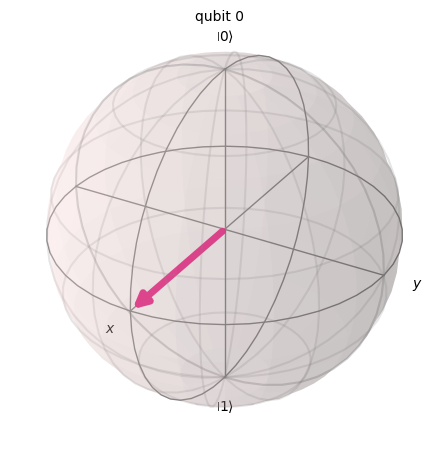

Amplitude of |0> = 0.0
Amplitude of |1> = 0.0
Amplitude of |0> = 0.0
Amplitude of |1> = 0.0


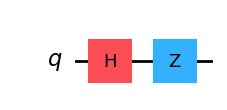

<IPython.core.display.Latex object>

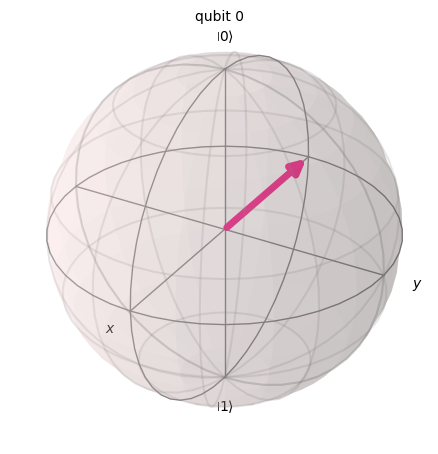

In [31]:
# First it starts with |0⟩ by default
qc = QuantumCircuit(1)

# makes superposition:
# first make |+>
# |+⟩ = (|0⟩ + |1⟩) / √2
qc.h(0)
state = Statevector.from_instruction(qc)
display(state.draw("latex"))
display(plot_bloch_multivector(state))

# now apply Z
qc.z(0)
'''
Z gate does this:

Z|0⟩ = |0⟩
Z|1⟩ = -|1⟩

So:

(|0⟩ + |1⟩) / √2

becomes:

(|0⟩ - |1⟩) / √2

This final state is called:

|-⟩

'''

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))
display(plot_bloch_multivector(state))

# Why we used H before Z?
# If we apply Z directly on |0⟩, nothing visible happens.
# So we first create |+⟩ using H, then Z shows its phase effect clearly.

## 1.5 Hadamard gate: H

The `H` gate creates superposition.

$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

So measurement gives around 50% `0` and 50% `1`.

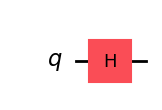

<IPython.core.display.Latex object>

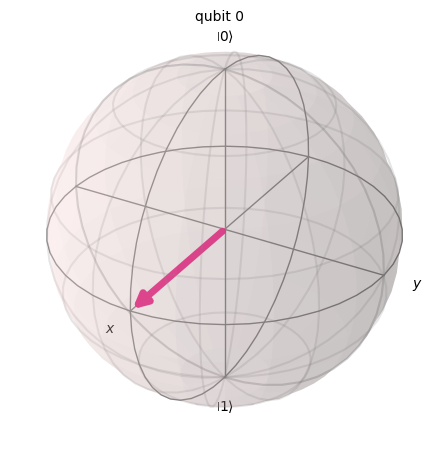

In [32]:
qc = QuantumCircuit(1)

qc.h(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))
display(plot_bloch_multivector(state))

### Measurement

Measurement converts quantum information into classical output.

For one qubit:

```text
Possible outputs: 0 or 1
```

For two qubits:

```text
Possible outputs: 00, 01, 10, 11
```

Measurement is probabilistic. So with 1024 shots, the exact counts may change every time.

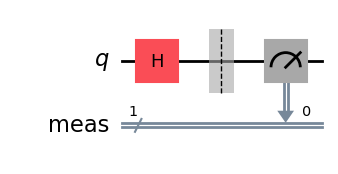

{'0': 512, '1': 512}


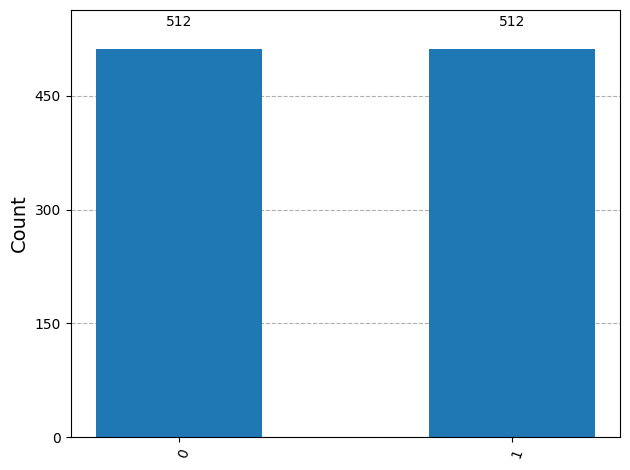

In [33]:
## Let's measure now
qc = QuantumCircuit(1)

qc.h(0)

qc.measure_all()

display(qc.draw(output="mpl"))

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))

# 9. Phase gates

Phase gates are required and the easiest to visualize when the qubit starts from $|+\rangle$.

Why?

As show above, if we start from $|0\rangle$, many phase gates appear to do nothing on the Bloch sphere. Starting from $|+\rangle$ puts the vector on the equator, where phase rotations are visible.

## 9.1 S gate

The `S` gate is a 90 degree phase rotation.

It is also equal to:

$$
S = \sqrt{Z}
$$

<IPython.core.display.Latex object>

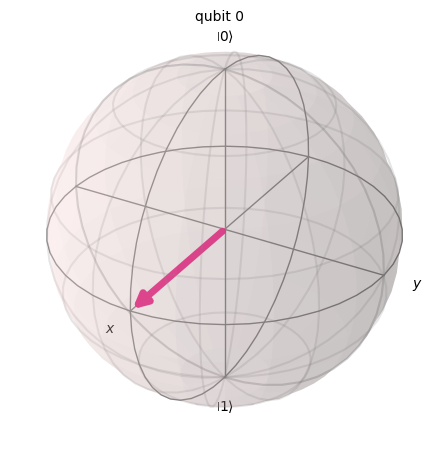

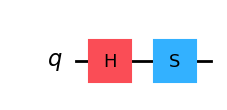

<IPython.core.display.Latex object>

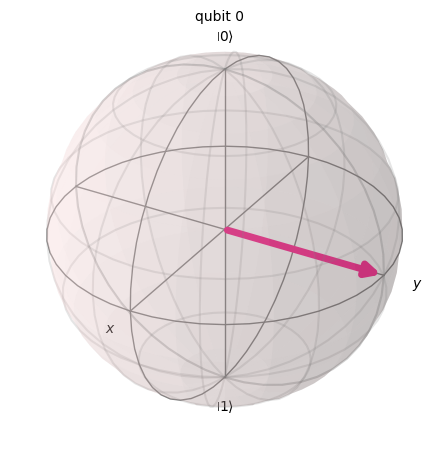

In [35]:
qc = QuantumCircuit(1)

qc.h(0)
state = Statevector.from_instruction(qc)
display(state.draw("latex"))
display(plot_bloch_multivector(state))

qc.s(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

## 9.2 Sdg gate

`Sdg` means S-dagger. It is the reverse of the `S` gate.

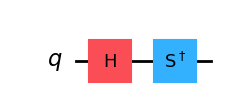

<IPython.core.display.Latex object>

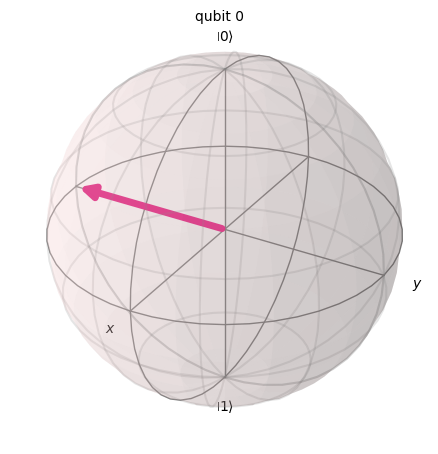

In [36]:
qc = QuantumCircuit(1)

qc.h(0)
qc.sdg(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

## 9.3 T gate

The `T` gate is a 45 degree phase rotation.

It is a smaller phase rotation than `S`.

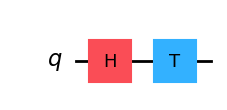

<IPython.core.display.Latex object>

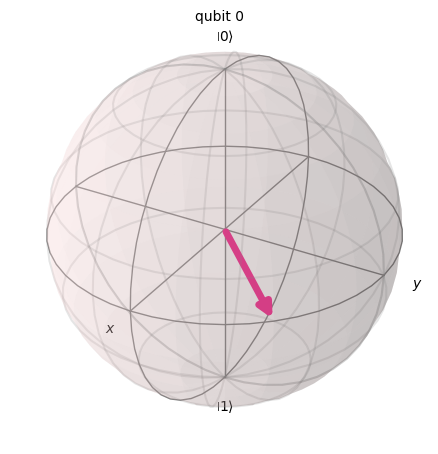

In [37]:
qc = QuantumCircuit(1)

qc.h(0)
qc.t(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

## 9.4 Tdg gate

`Tdg` means T-dagger. It is the reverse of the `T` gate.

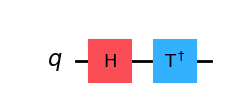

<IPython.core.display.Latex object>

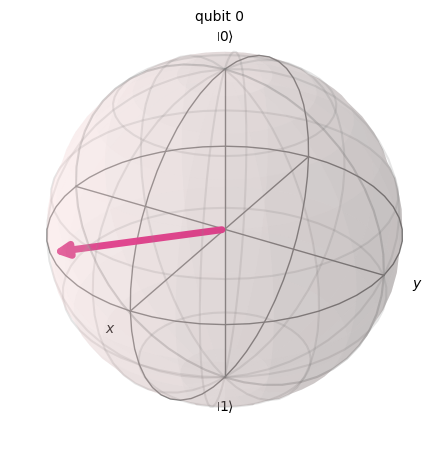

In [38]:
qc = QuantumCircuit(1)

qc.h(0)
qc.tdg(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

## 9.5 P gate / Phase gate

The `P` gate lets us choose the phase angle.

$$
P(\theta)
$$

In Qiskit:

```python
qc.p(theta, 0)
```

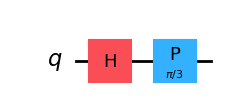

<IPython.core.display.Latex object>

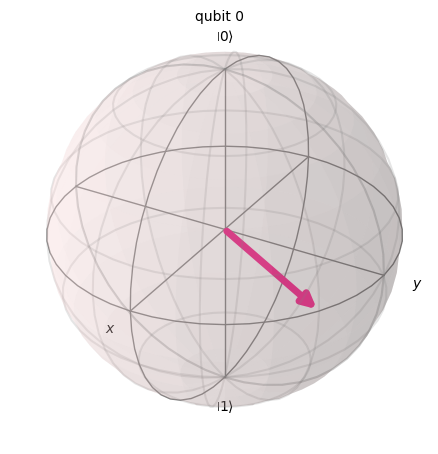

In [39]:
theta = np.pi / 3

qc = QuantumCircuit(1)

qc.h(0)
qc.p(theta, 0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

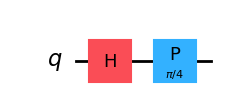

<IPython.core.display.Latex object>

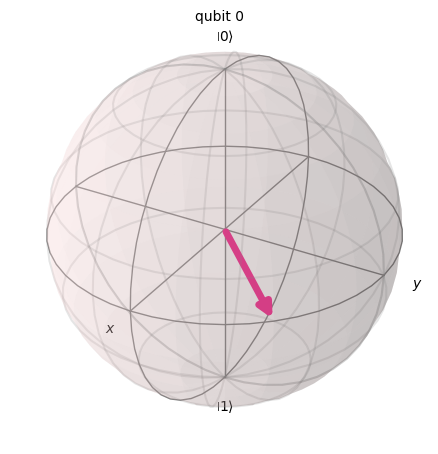

In [40]:
theta = np.pi / 4

qc = QuantumCircuit(1)

qc.h(0)
qc.p(theta, 0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

# 10. Rotation gates

Rotation gates rotate the qubit vector around the X, Y, or Z axis.

```text
Rx(theta) -> rotation around X-axis
Ry(theta) -> rotation around Y-axis
Rz(theta) -> rotation around Z-axis
```



## 10.1 Rx gate

`Rx(theta)` rotates around the X-axis.

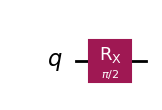

<IPython.core.display.Latex object>

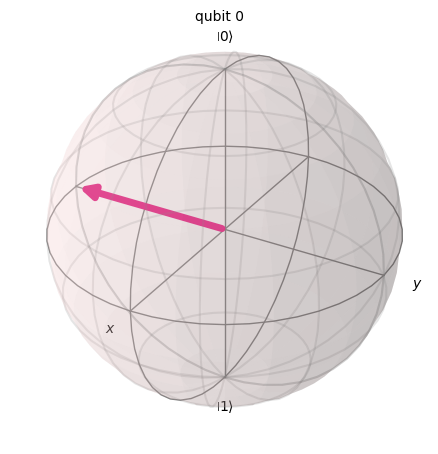

In [43]:
theta = np.pi / 2

qc = QuantumCircuit(1)

qc.rx(theta, 0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

## 10.2 Ry gate

`Ry(theta)` rotates around the Y-axis.

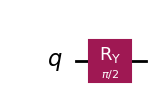

<IPython.core.display.Latex object>

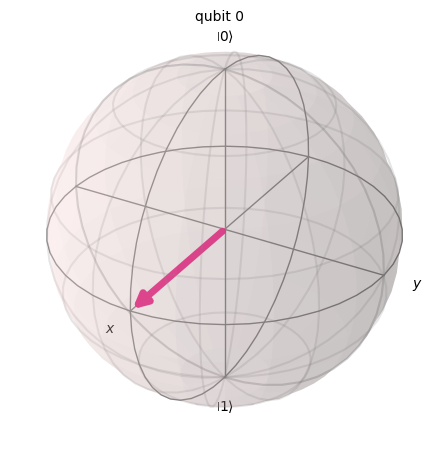

In [48]:
theta = np.pi / 2

qc = QuantumCircuit(1)

qc.ry(theta, 0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

## 10.3 Rz gate

`Rz(theta)` rotates around the Z-axis.

To see it clearly, start from $|+\rangle$.

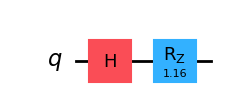

<IPython.core.display.Latex object>

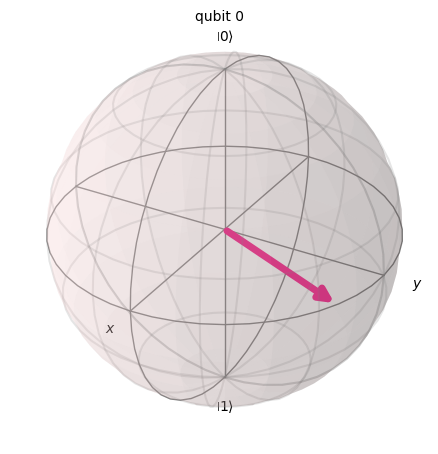

In [50]:
theta = np.pi / 2.7

qc = QuantumCircuit(1)

qc.h(0)
qc.rz(theta, 0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

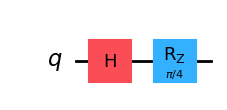

<IPython.core.display.Latex object>

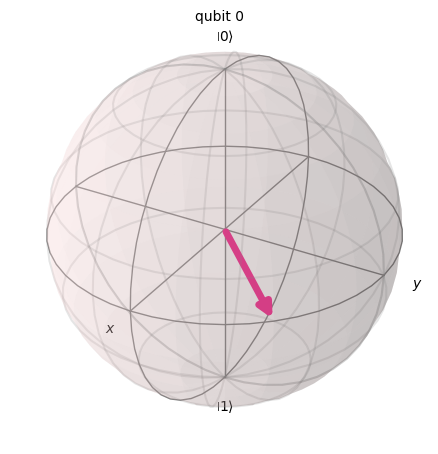

In [51]:
theta = np.pi / 4

qc = QuantumCircuit(1)

qc.h(0)

# Try changing this gate:
qc.rz(theta, 0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

# 11. General U gate

It is useful because many single-qubit operations can be represented using three angles.

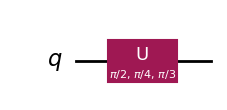

<IPython.core.display.Latex object>

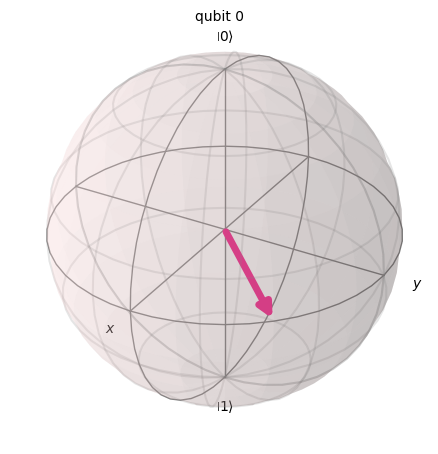

In [52]:
theta = np.pi / 2
phi = np.pi / 4
lam = np.pi / 3

qc = QuantumCircuit(1)

qc.u(theta, phi, lam, 0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(plot_bloch_multivector(state))

# 14. Two-qubit gates

## 14.1 CNOT / CX gate

The `CX` gate has:

```text
control qubit
target qubit
```

Simple rule:

```text
If control = 1, flip target.
If control = 0, do nothing to target.
```

In Qiskit:

```python
qc.cx(control, target)
```

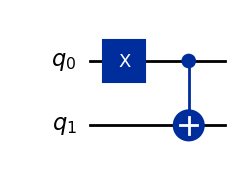

<IPython.core.display.Latex object>

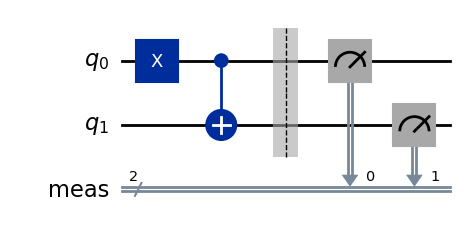

{'11': 1024}


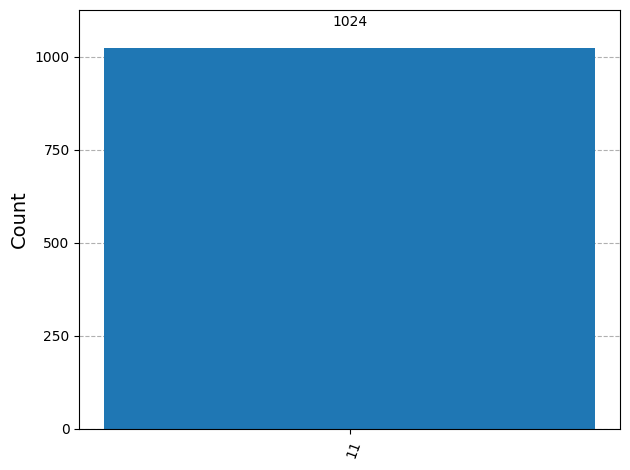

In [66]:
qc = QuantumCircuit(2)

qc.x(0)        # make q0 = 1

# applies CNOT: if q0 is 1, flip q1
# control qubit = q0
# target qubit  = q1
qc.cx(0, 1)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))

qc.measure_all()

display(qc.draw(output="mpl"))

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))

## moral of the story is: CNOT flips the second qubit only when the first qubit is 1.

## 14.2 CZ gate

The `CZ` gate is a controlled phase gate.

Simple idea:

```text
If both qubits are 1, add a phase of -1.
```

Its effect may not always be visible in direct measurement, because measurement only shows probabilities, not phase.

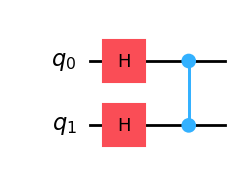

<IPython.core.display.Latex object>

In [68]:
# create 2 qubits
qc = QuantumCircuit(2)

# apply Hadamard on both qubits.
qc.h(0)
qc.h(1)

# now both become superposition
# q0 = (|0⟩ + |1⟩) / √2
# q1 = (|0⟩ + |1⟩) / √2
# in total the state becomes: (|00⟩ + |01⟩ + |10⟩ + |11⟩) / 2

# apply, controlled-z gate... ff both qubits are 1, add minus (phase) sign to |11⟩.
qc.cz(0, 1)

display(qc.draw(output="mpl"))
state = Statevector.from_instruction(qc)
display(state.draw("latex"))

## moral of the story: CZ does not flip the qubit.
# CZ adds a phase/sign change when both qubits are 1.

## 14.3 SWAP gate

The `SWAP` gate exchanges the states of two qubits.

```text
q0 state goes to q1
q1 state goes to q0
```

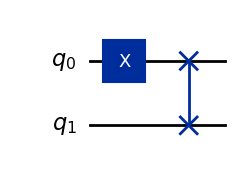

<IPython.core.display.Latex object>

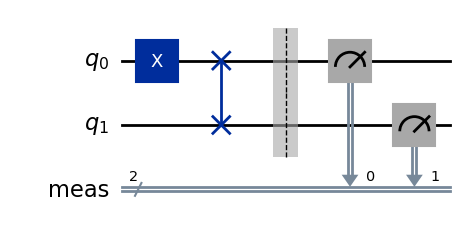

{'10': 1024}


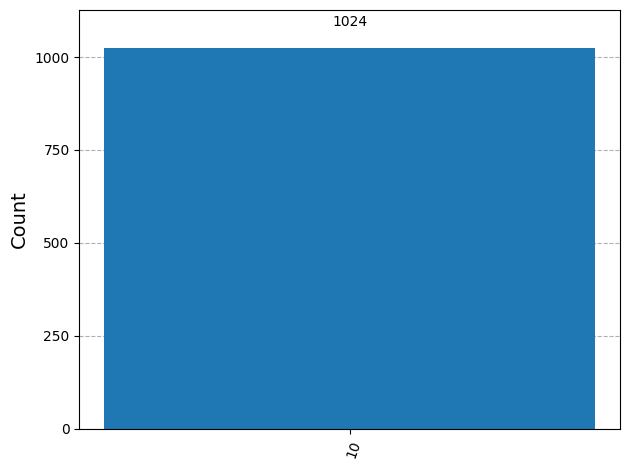

In [69]:
qc = QuantumCircuit(2)

qc.x(0)        # q0 = 1, q1 = 0
qc.swap(0, 1)  # now q0 = 0, q1 = 1

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))

qc.measure_all()

display(qc.draw(output="mpl"))

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))

## moral of the satori SWAP gate exchanges the states of two qubits. It does not create entanglement here!

# 15. Entanglement

Entanglement is a special quantum connection between qubits.

A simple two-qubit entangled state is the Bell state:

$$
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
$$

Simple meaning:

- The result is not fixed before measurement.
- But when measured, both qubits match.
- We get mostly `00` and `11`, not `01` and `10`.

## 15.1 Bell state circuit

Steps:

1. Apply `H` on qubit 0.
2. Apply `CX` from qubit 0 to qubit 1.

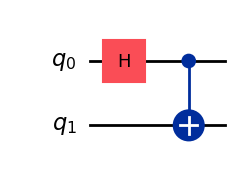

In [74]:
# lets create 2 qubits
    # q0 = |0⟩
    # q1 = |0⟩
# so now the initial state is :
# |00⟩
qc = QuantumCircuit(2)

# Apply Hadamard gate on q0
qc.h(0)
# now q0 goes into superposition: q0 = (|0⟩ + |1⟩) / √2
# and q1 = |0⟩
# their combined state is:
# (|00⟩ + |10⟩) / √2

# this line applies CNOT gate
qc.cx(0, 1)
# we know what is does: if q0 is 1, flip q1
# so:
# |00⟩ stays |00⟩
# |10⟩ becomes |11⟩
# now the final "Bell" state is:
# (|00⟩ + |11⟩) / √2

'''
moral of the stori:
The two qubits are now linked.

If q0 is measured as 0, q1 will also be 0.
If q0 is measured as 1, q1 will also be 1.

This is Entanglement

So the qubits are not random independently.
--> They are correlated.

It also means the information is stored in the joint two-qubit state, not in each qubit alone.
'''

display(qc.draw(output="mpl"))
state = Statevector.from_instruction(qc)
# display(state.draw("latex"))

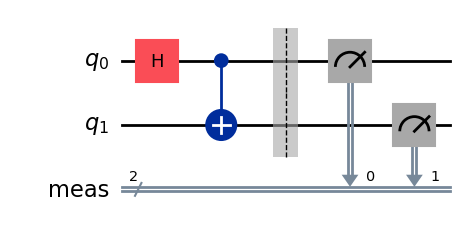

{'11': 509, '00': 515}


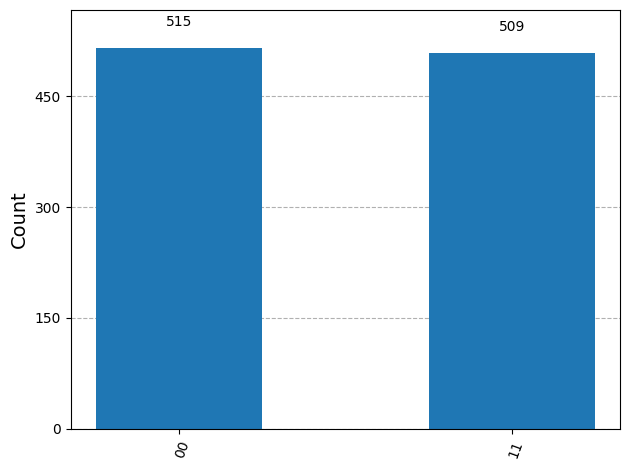

In [75]:
# let's add the measurement code
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.measure_all()

display(qc.draw(output="mpl"))

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))



## 15.2 Compare with a non-entangled two-qubit superposition

Now compare the Bell state with this circuit:

```python
H on q0
H on q1
```

This creates all four outputs with almost equal probability:

```text
00, 01, 10, 11
```

This is superposition, but not the same Bell-type correlation.

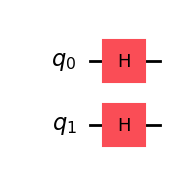

<IPython.core.display.Latex object>

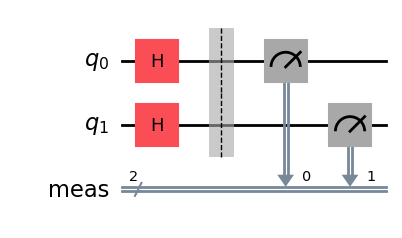

{'00': 260, '10': 239, '01': 272, '11': 253}


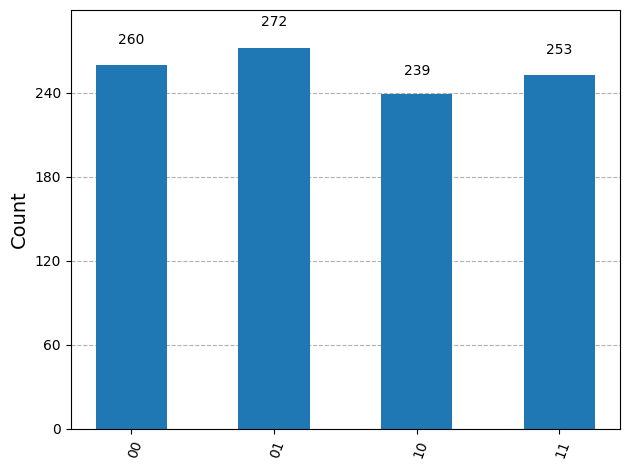

In [73]:
qc = QuantumCircuit(2)

qc.h(0)
qc.h(1)

display(qc.draw(output="mpl")) ## Here we apply H gate on both qubits separately.
# so, q0 becomes superposition and q1 becomes superposition
# finale state == (|00⟩ + |01⟩ + |10⟩ + |11⟩) / 2
# means, all 4 possible outputs are possible, yes?
# 00
# 01
# 10
# 11

state = Statevector.from_instruction(qc)
display(state.draw("latex"))
qc.measure_all()

display(qc.draw(output="mpl"))

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))

## moral of the story: here the qubits are NOT linked
## remember::
    # Entangled state gives correlated results.
    # Non-entangled superposition gives independent random results.


# The Four Bell states

There are four standard Bell states.

We can create them by adding small changes before or after the basic Bell circuit.

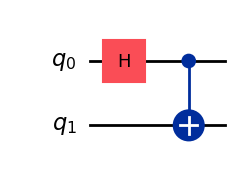

<IPython.core.display.Latex object>

{'00': 516, '11': 508}


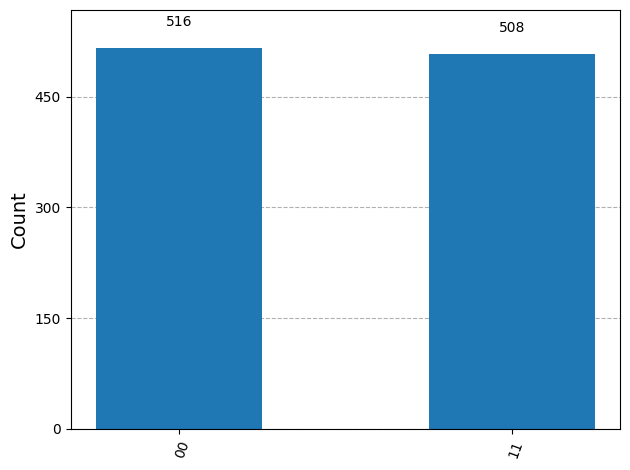

In [76]:
## Phi plus

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))

qc.measure_all()

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))

'''
 final state == (|00⟩ + |11⟩) / √2

'''

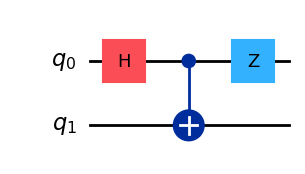

<IPython.core.display.Latex object>

{'11': 511, '00': 513}


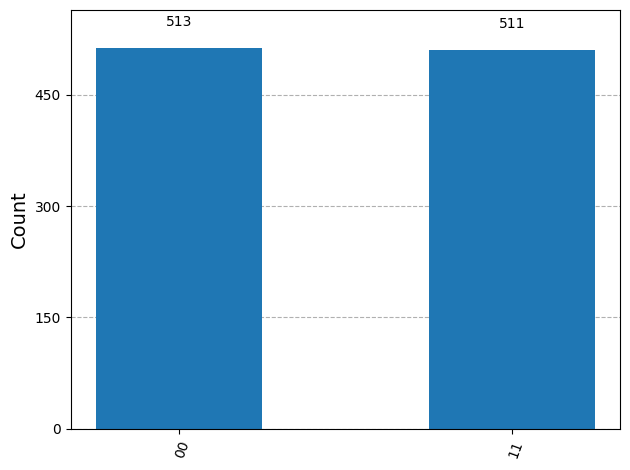

In [77]:
## Phi minus

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.z(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))

qc.measure_all()

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))

'''
 final state from (|00⟩ + |11⟩) / √2 to (|00⟩ - |11⟩) / √2. Adds a minus sign to the second qubit. which is phase

'''

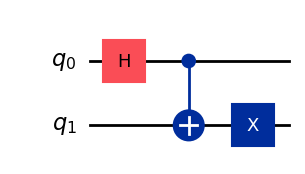

<IPython.core.display.Latex object>

{'01': 496, '10': 528}


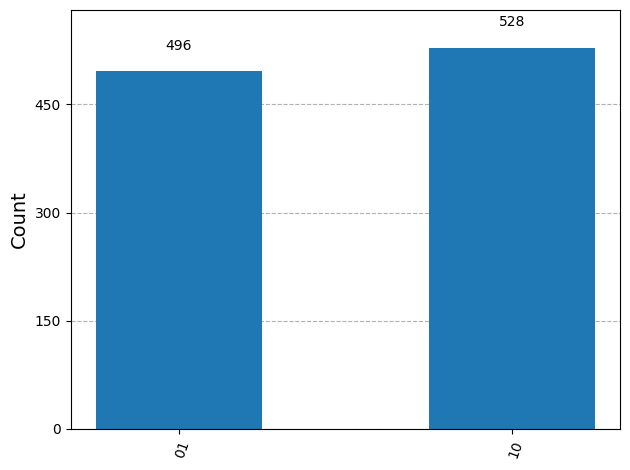

In [78]:
## Psi plus

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.x(1)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))

qc.measure_all()

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))

'''
 final state from (|00⟩ + |11⟩) / √2 to (|01⟩ + |10⟩) / √2. Means, both qubits are opposite

'''

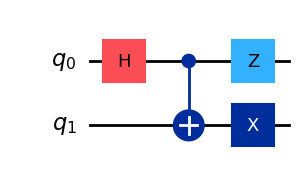

<IPython.core.display.Latex object>

{'01': 522, '10': 502}


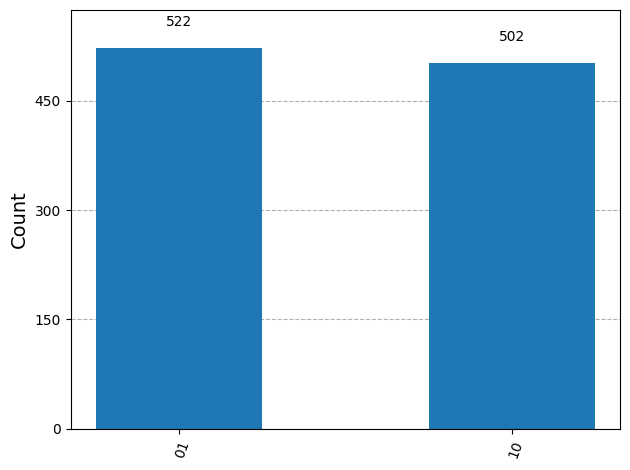

In [79]:
# Psi minus

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))

qc.measure_all()

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
display(plot_histogram(counts))

'''
 final state from (|00⟩ + |11⟩) / √2 to (|01⟩ - |10⟩) / √2. Again means, both qubits are opposite, but with a minus sign

'''

* Bell states are maximally entangled states.
* In Φ states, qubits are same.
* In Ψ states, qubits are opposite.
* The plus/minus sign is phase information.




In [57]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

fig = qc.draw(output="mpl", fold=-1)
fig.savefig("bell_state_circuit.png", dpi=300, bbox_inches="tight")
print("Saved: bell_state_circuit.png")

Saved: bell_state_circuit.png


# What are circuits?


The circuit runs **left to right**.

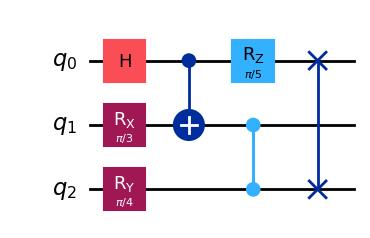

<IPython.core.display.Latex object>

In [58]:
## Sample circuit

qc = QuantumCircuit(3)

qc.h(0)
qc.rx(np.pi / 3, 1)
qc.ry(np.pi / 4, 2)

qc.cx(0, 1)
qc.cz(1, 2)

qc.rz(np.pi / 5, 0)
qc.swap(0, 2)

display(qc.draw(output="mpl", fold=-1))
# display(qc.draw(output="text", fold=-1))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))

## Quantu coin toss circuit

1. Quantum Coin Toss using Hadamard Gate
2. Initial state = |0>
3. Apply H gate
4. Final state = (|0> + |1>) / sqrt(2)
5. Expected measurement result:
    * about 50% |0> and 50% |1>


Step 1: Initial circuit


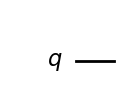

Initial statevector:


<IPython.core.display.Latex object>

Initial Bloch sphere:


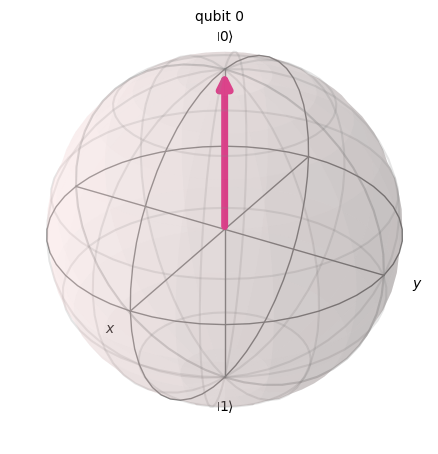

In [5]:
qc = QuantumCircuit(1)

print("Step 1: Initial circuit")
display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

print("Initial statevector:")
display(state.draw("latex"))

print("Initial Bloch sphere:")
display(plot_bloch_multivector(state))

In [6]:
## here is the Hadamard matrix

H = (1 / np.sqrt(2)) * np.array([[1, 1],
                                 [1, -1]])

print("Hadamard matrix H =")
print(H)
'''
This is the matrix form of the Hadamard gate:
H = (1/√2) [ [1, 1],
             [1,-1] ]

It converts |0⟩ into equal superposition.


'''

Hadamard matrix H =
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


Step 2: After applying H gate


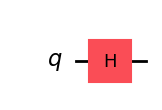

Final statevector:


<IPython.core.display.Latex object>

Bloch sphere after H gate:


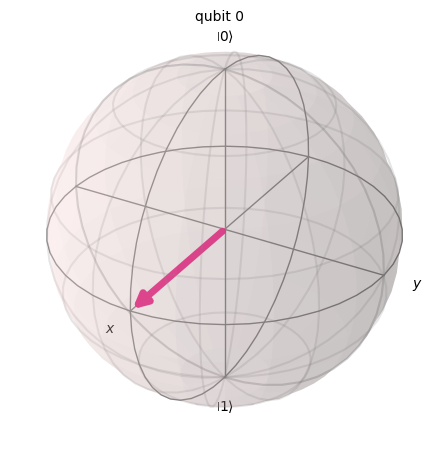

In [7]:
## Now let's apply Hadamard gate
qc = QuantumCircuit(1)

qc.h(0)

print("Step 2: After applying H gate")
display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

print("Final statevector:")
display(state.draw("latex"))

print("Bloch sphere after H gate:")
display(plot_bloch_multivector(state))
'''
qc.h(0) means apply H gate on qubit 0

Final state becomes:
(|0⟩ + |1⟩) / √2

On Bloch sphere, the arrow moves from the top to the equator - This shows the qubit is now in superposition

'''

In [8]:
## show probabilities before meeasurements
qc = QuantumCircuit(1)

qc.h(0)

state = Statevector.from_instruction(qc)

print("Statevector:")
display(state.draw("latex"))

probs = state.probabilities_dict()

print("theoretical probabilities:")
print(probs)

Statevector:


<IPython.core.display.Latex object>

Probabilities:
{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


Step 3: Circuit with measurement


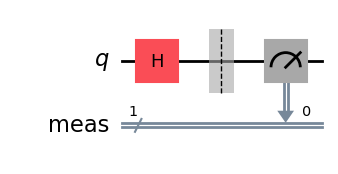

Measurement counts:
{'0': 535, '1': 489}


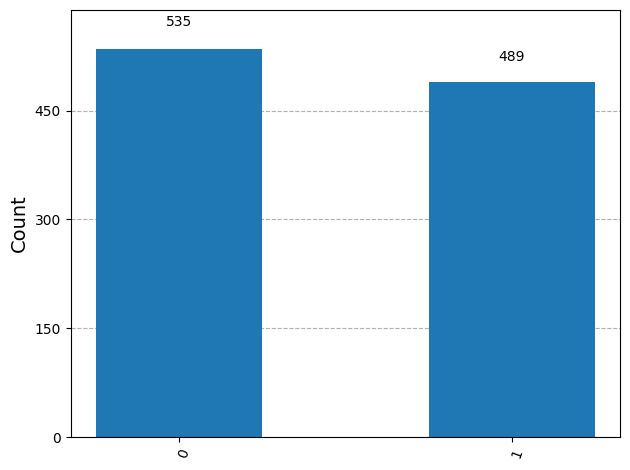

In [15]:
## Let's run this cicuit and measure
qc = QuantumCircuit(1)

qc.h(0)
qc.measure_all()

print("Step 3: Circuit with measurement")
display(qc.draw(output="mpl"))

simulator = AerSimulator()

# shots=1024 means run the same circuit 1024 times
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Measurement counts:")
print(counts)

display(plot_histogram(counts))

### Conclusion:
1. We start with |0⟩.
2. Then we apply Hadamard gate.
3. Hadamard creates an equal superposition of |0⟩ and |1⟩.
4. So when we measure many times, we get about 50% 0 and 50% 1.
5. That is why this acts like a quantum coin toss.

## Double Hadamard Gate

|0⟩ -----> H -----> H -----> |0⟩

**Main idea:**

* Hadamard gate creates superposition.

* But if we apply Hadamard twice, it brings the qubit back to the original state.

* H followed by H = no change

**Mathematically:**

    H² = I

So:

    H|0⟩ = (|0⟩ + |1⟩)/√2

    H(H|0⟩) = |0⟩


This shows reversibility.


Full Double Hadamard circuit:


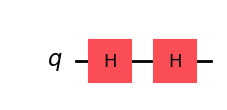

In [16]:
## Let's create this circuit:
qc = QuantumCircuit(1)

qc.h(0)
qc.h(0)

print("Full Double Hadamard circuit:")
display(qc.draw(output="mpl"))

Step 0: Initial state


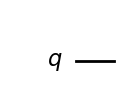

Statevector:


<IPython.core.display.Latex object>

Bloch sphere:


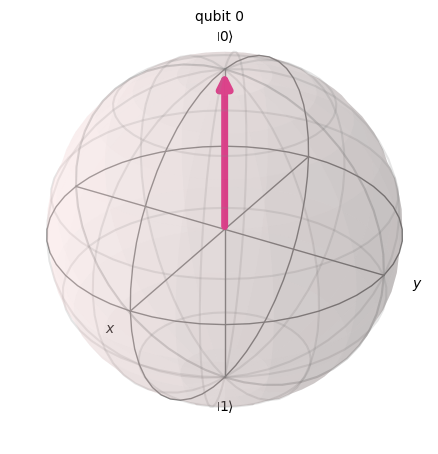

In [17]:
## visualising the initial state:
qc = QuantumCircuit(1)

print("Step 0: Initial state")

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

print("Statevector:")
display(state.draw("latex"))

print("Bloch sphere:")
display(plot_bloch_multivector(state))

Step 1: After first H gate


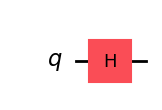

Statevector:


<IPython.core.display.Latex object>

Bloch sphere:


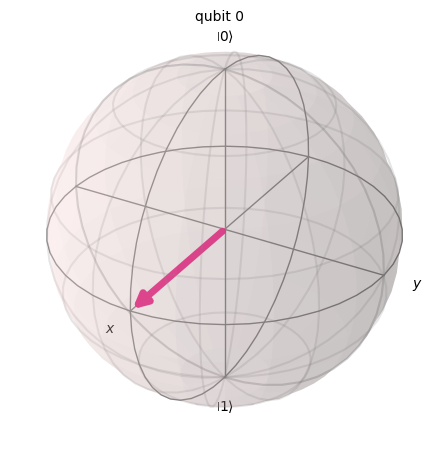

In [18]:
## After applying the first Hadamard

qc = QuantumCircuit(1)

qc.h(0)

print("Step 1: After first H gate")

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

print("Statevector:")
display(state.draw("latex"))

print("Bloch sphere:")
display(plot_bloch_multivector(state))

'''
First H gate changes |0> into superposition.

|0> becomes:

(|0> + |1>) / sqrt(2)

Now the Bloch sphere arrow moves to the equator.

'''

Step 2: After second H gate


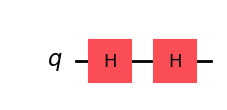

Statevector:


<IPython.core.display.Latex object>

Bloch sphere:


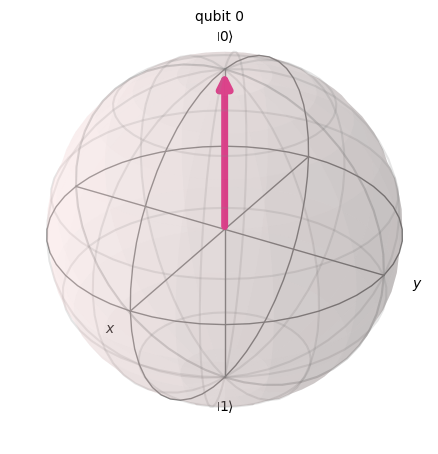

In [19]:
## now after applying second Hadamard:

qc = QuantumCircuit(1)

qc.h(0)
qc.h(0)

print("Step 2: After second H gate")

display(qc.draw(output="mpl"))

state = Statevector.from_instruction(qc)

print("Statevector:")
display(state.draw("latex"))

print("Bloch sphere:")
display(plot_bloch_multivector(state))

'''
Second H gate reverses the first H gate.

The qubit comes back to |0>.

Bloch sphere arrow goes back to the top.

'''

In [21]:
## let's see the probabilities
qc = QuantumCircuit(1)

qc.h(0)
qc.h(0)

state = Statevector.from_instruction(qc)

print("Final statevector:")
display(state.draw("latex"))

probs = state.probabilities_dict()

print("Final probabilities:")
print(probs)

'''
means:
100% chance of measuring 0.
0% chance of measuring 1.

'''

Final statevector:


<IPython.core.display.Latex object>

Final probabilities:
{np.str_('0'): np.float64(0.9999999999999996)}


Circuit with measurement:


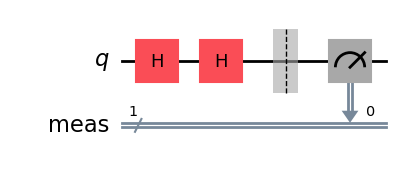

Measurement counts:
{'0': 1024}


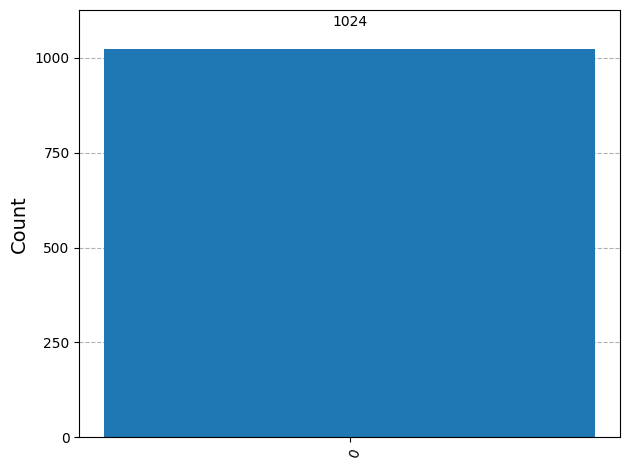

In [22]:
## and if we run and measure, we get:

qc = QuantumCircuit(1)

qc.h(0)
qc.h(0)

qc.measure_all()

print("Circuit with measurement:")
display(qc.draw(output="mpl"))

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Measurement counts:")
print(counts)

display(plot_histogram(counts))

'''
means:
All measurements give 0.

'''

### Conclusion

We start with |0>

First H gate creates a 50-50 superposition:

    (|0> + |1>) / sqrt(2)

Second H gate reverses this operation.

So the final state becomes |0> again.

This proves that H is reversible.

Applying H twice is the same as doing nothing.


*IMPORTANT NOTE:*

* One H gives randomness during measurement
* But two H gates removes that randomness and return the qubit to |0>.

